In [1]:
import sys
sys.path.insert(0, "/global/cfs/cdirs/desicollab/users/bautista/bgs/desi_pv_mocks")

In [7]:
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM
import matplotlib.pyplot as plt

from desi_pv_mocks.config import load_config
cfg=load_config('../config_files/mock_config_DR1.yaml')


cosmo = FlatLambdaCDM(H0=100, Om0=0.3151)


In [8]:
d_data = Table.read(cfg.data_tf_clus_data).to_pandas()
d_rand = Table.read(cfg.data_tf_clus_rand).to_pandas()
d_data["LOGDIST"]           = (
        np.log10(cosmo.luminosity_distance(d_data["Z"]).value)
        + 5.0
        - d_data["MU"] / 5.0
    )
d_data["LOGDIST_ERR"]       = d_data["MU_ERR"] / 5.0
d_data["LOGDIST_GAUSS_ERR"] = d_data["LOGDIST_ERR"].copy()

print(d_data.columns)
print(d_rand.columns)
print(len(d_data), len(d_rand), len(d_rand)/len(d_data))
data_label = f'TF clus data {cfg.data_tf_full_version}'

Index(['TARGETID', 'SGA_ID', 'RA', 'DEC', 'Z', 'ZCMB', 'WEIGHT', 'NPV',
       'NDENS', 'MU', 'MU_ERR', 'LOGDIST', 'LOGDIST_ERR', 'LOGDIST_GAUSS_ERR'],
      dtype='str')
Index(['RA', 'DEC', 'Z', 'ZCMB', 'WEIGHT', 'NPV', 'NDENS', 'MU_ERR',
       'LOGDIST_ERR', 'PV_ERR'],
      dtype='str')
6806 136120 20.0


In [9]:
m_data = Table.read(cfg.mock_tf_clus_data.format(phase=0, real=0)).to_pandas()
m_rand = Table.read(cfg.mock_tf_clus_rand.format(phase=0)).to_pandas()
print(m_rand)
print(len(m_data), len(m_rand), len(m_rand)/len(m_data), m_rand['WEIGHT'].sum() )
mock_label = f'TF clus mock {cfg.version_tf_clus}'

                RA        DEC         Z  WEIGHT       NPV     NDENS  \
0       321.938136  -1.241606  0.042308     1.0  0.000924  0.018038   
1       200.409111  35.587947  0.092562     1.0  0.000065  0.020922   
2       194.168041   4.349026  0.050688     1.0  0.000613  0.019387   
3       233.823837  13.332421  0.037899     1.0  0.000695  0.012392   
4        13.600229  19.883439  0.062218     1.0  0.000327  0.017557   
...            ...        ...       ...     ...       ...       ...   
122235  257.933620  27.128747  0.051567     1.0  0.000425  0.015882   
122236  357.721867  -6.641244  0.033702     1.0  0.000875  0.012113   
122237  113.453923  39.330442  0.091024     1.0  0.000057  0.020209   
122238  181.561526  35.171719  0.083919     1.0  0.000163  0.019030   
122239  181.013463  33.214253  0.027812     1.0  0.000785  0.010531   

        LOGDIST_ERR       PV_ERR  
0          0.103729  3062.115384  
1          0.105394  6907.990154  
2          0.108325  3840.107494  
3      

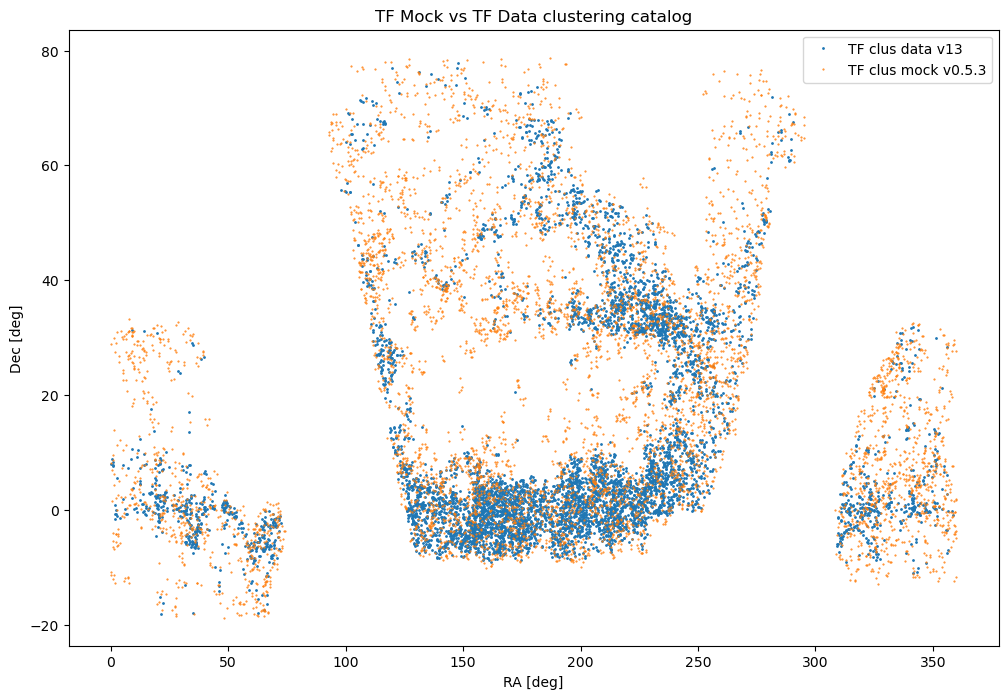

In [10]:
plt.figure(figsize=(12, 8))
plt.plot(d_data['RA'], d_data['DEC'], '.', ms=2, alpha=1, label=data_label)
plt.plot(m_data['RA'], m_data['DEC'], '.', ms=1, alpha=1, label=mock_label )
plt.title('TF Mock vs TF Data clustering catalog')
plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]')
plt.legend()

Text(0, 0.5, 'Dec [deg]')

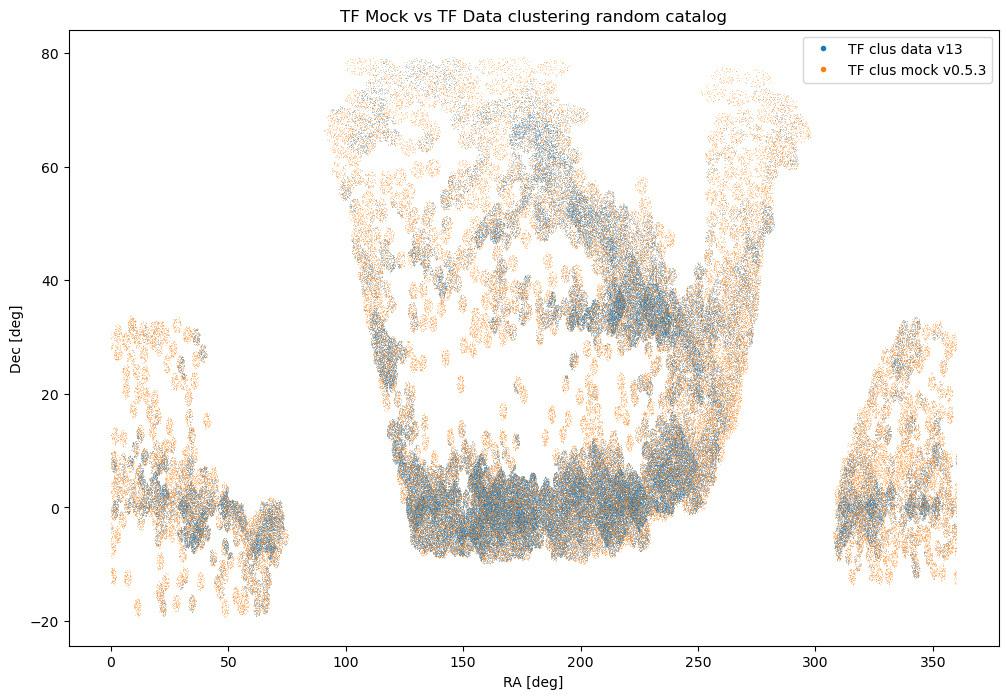

In [11]:
plt.figure(figsize=(12, 8))
plt.plot(d_rand['RA'][::], d_rand['DEC'][::], ',', ms=0.5, alpha=0.3)
plt.plot(m_rand['RA'][::], m_rand['DEC'][::], ',', ms=0.5, alpha=0.3)

plt.plot([], [], 'C0.', label=data_label)
plt.plot([], [], 'C1.', label=mock_label)

plt.title('TF Mock vs TF Data clustering random catalog')
plt.legend()
plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]') 

In [12]:
def read_mocks():
    mocks = []
    for phase in range(1):
        for real in range(27):
            mock = Table.read(cfg.mock_tf_clus_data.format(phase=phase, real=real)).to_pandas()
            mock['PHASE'] = phase
            mock['REAL'] = real
            mocks.append(mock)
    mocks = pd.concat(mocks)
    return mocks

In [13]:
mocks = read_mocks()

9


Text(0.5, 0, 'Redshift')

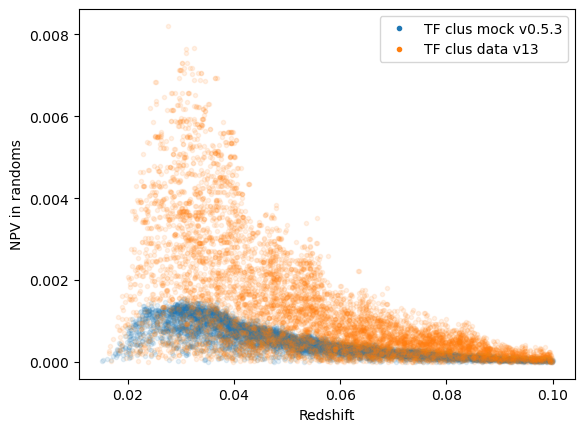

In [16]:
for phase in range(1):
    for real in range(1):
        m_data_temp = mocks[(mocks['PHASE']==phase) & (mocks['REAL']==real)]
        w = m_data_temp['NPV']!=0
        plt.plot(m_data_temp['Z'][w], m_data_temp['NPV'][w], 'C0.', alpha=0.1) 
        print(np.sum(~w))
plt.plot(d_data['Z'], d_data['NPV'], 'C1.', alpha=0.1) 
plt.plot([],[], 'C0.', label=mock_label)
plt.plot([],[], 'C1.', label=data_label)
plt.legend()
plt.ylabel('NPV in randoms')
plt.xlabel("Redshift")

0


Text(0.5, 0, 'Redshift')

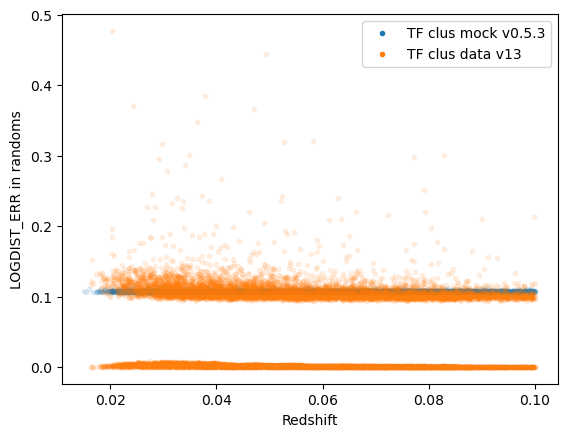

In [17]:
for phase in range(1):
    for real in range(1):
        m_data_temp = mocks[(mocks['PHASE']==phase) & (mocks['REAL']==real)]
        w = m_data_temp['LOGDIST_ERR']!=0
        plt.plot(m_data_temp['Z'][w], m_data_temp['LOGDIST_ERR'][w], 'C0.', alpha=0.1) 
        print(np.sum(~w))
plt.plot(d_data['Z'], d_data['LOGDIST_ERR'], 'C1.', alpha=0.1)
plt.plot(d_data['Z'], d_data['NPV'], 'C1.', alpha=0.1) 
plt.plot([],[], 'C0.', label=mock_label)
plt.plot([],[], 'C1.', label=data_label)
plt.legend()
plt.ylabel('LOGDIST_ERR in randoms')
plt.xlabel("Redshift")

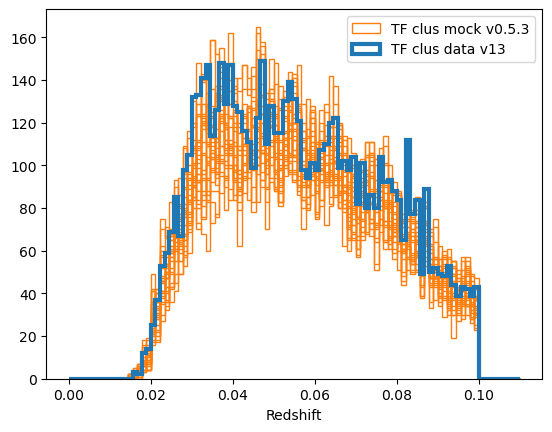

In [18]:
zbins = np.linspace(0, 0.11, 100)
for phase in range(1):
    for real in range(27):
        m_data_temp = mocks[(mocks['PHASE']==phase) & (mocks['REAL']==real)]
        label = mock_label if phase == 0 and real ==0 else None 
        _=plt.hist(m_data_temp['Z'], color='C1', bins=zbins, histtype='step', alpha=1, label=label)

_=plt.hist(d_data['Z'], bins=zbins, histtype='step', lw=3,
           label=data_label)

plt.xlabel('Redshift')
plt.legend()

In [19]:
area_ngc = 8500.3589 # sq deg
area_sgc = 3610.6785 # sq deg

area_tot = area_ngc + area_sgc # sq deg

zbins = np.linspace(0, 0.11, 100)
zcen = 0.5*(zbins[:-1]+zbins[1:]) 
zvol = (cosmo.comoving_volume(zbins[1:]).value-cosmo.comoving_volume(zbins[:-1]).value)*(1/(4.*np.pi*((180./np.pi)**2)))

def get_nz(z, weights=None,  area=area_tot):
    nz, _ = np.histogram(z, bins=zbins, weights=weights)
    return nz/zvol/area

In [20]:
m_nzs = []
for phase in range(1):
    for real in range(27):
        m_data_temp = mocks[(mocks['PHASE']==phase) & (mocks['REAL']==real)]
        m_nz = get_nz(m_data_temp['Z'], area=area_tot)
        m_nzs.append(m_nz)
m_nzs = np.array(m_nzs) 
print(m_nzs.shape)

(27, 99)


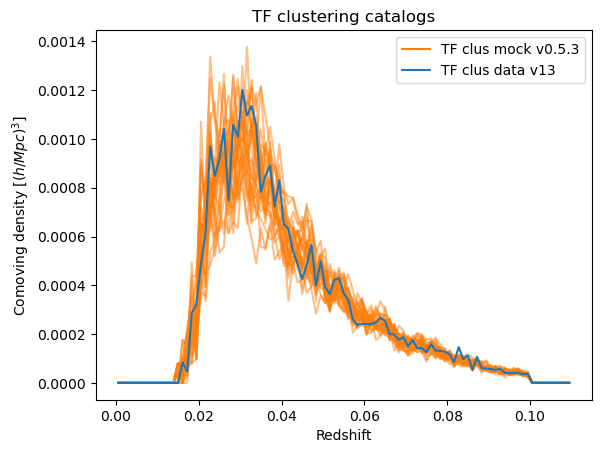

In [21]:
for m_nz in m_nzs:      
    plt.plot(zcen, m_nz, 'C1-', alpha=0.5)
plt.plot([], [], 'C1-', label=mock_label)

d_nz = get_nz(d_data['Z'], weights=d_data['WEIGHT'], area=area_tot)
plt.plot(zcen, d_nz, 'C0-', label=data_label)

plt.ylabel('Comoving density [${(h/Mpc)}^3$]')
plt.xlabel('Redshift')
plt.title('TF clustering catalogs')
plt.legend()
plt.savefig(f'../plots/nz_TF_clus_DR1_mock_{cfg.version_tf_clus}_data_{cfg.data_tf_full_version}.pdf')

In [22]:
def get_mean_std_counts(x, y, xbins):
    mean, _ = np.histogram(x, bins=xbins, weights=y)
    var, _ = np.histogram(x, bins=zbins, weights=y**2)
    counts, _ = np.histogram(x, bins=zbins) 
    mean = mean/counts
    var = var/counts - (mean)**2
    std = np.sqrt(var)
    return mean, std, counts

def get_stats(mocks, x_name, y_name, xbins):
    stats = {'counts': [], 'mean': [], 'std': []} 
    for phase in range(1):
        for real in range(27):
            mock = mocks[(mocks['PHASE'] == phase)&(mocks['REAL']==real)]
            mean, std, counts = get_mean_std_counts(mock[x_name], mock[y_name], xbins)
            stats['counts'].append(counts) 
            stats['mean'].append(mean) 
            stats['std'].append(std)

    stats['mean_of_mean'] = np.mean(np.array(stats['mean']), axis=0)
    stats['std_of_mean'] = np.std(np.array(stats['mean']), axis=0)
    stats['mean_of_std'] = np.mean(np.array(stats['std']), axis=0)
    stats['std_of_std'] = np.std(np.array(stats['std']), axis=0)
    stats['std_max'] = np.max(np.array(stats['std']), axis=0)
    stats['std_min'] = np.min(np.array(stats['std']), axis=0)
    stats['mean_max'] = np.max(np.array(stats['mean']), axis=0)
    stats['mean_min'] = np.min(np.array(stats['mean']), axis=0)

    return stats



/tmp/ipykernel_65048/2000261273.py:5: RuntimeWarning: invalid value encountered in divide
  mean = mean/counts
/tmp/ipykernel_65048/2000261273.py:6: RuntimeWarning: invalid value encountered in divide
  var = var/counts - (mean)**2
/tmp/ipykernel_65048/2000261273.py:7: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(var)


Text(0.5, 0, 'Redshift')

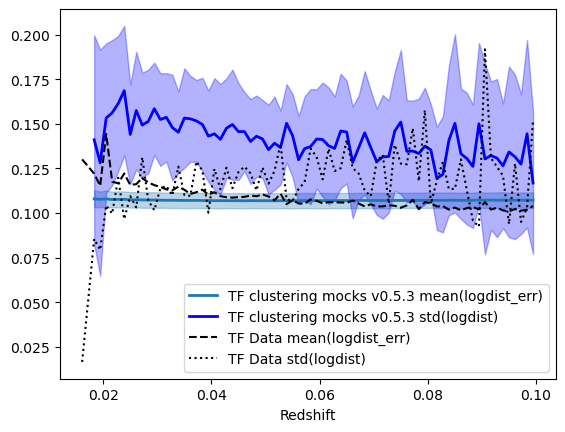

In [23]:
zbins = np.linspace(0, 0.11, 100)
zcen = 0.5*(zbins[1:]+zbins[:-1])

err_stats = get_stats(mocks, 'Z', 'LOGDIST_ERR', zbins)
ld_stats = get_stats(mocks, 'Z', 'LOGDIST', zbins)


plt.plot(zcen, err_stats['mean_of_mean'], 'C0-', lw=2, label=f'TF clustering mocks {cfg.version_tf_clus} mean(logdist_err)')
plt.fill_between(zcen, 
                 err_stats['mean_of_mean']+err_stats['std_of_mean'],
                 err_stats['mean_of_mean']-err_stats['std_of_mean'], 
                 color='C0', alpha=0.3)

plt.plot(zcen, ld_stats['mean_of_std'], 'b-', lw=2, label=f'TF clustering mocks {cfg.version_tf_clus} std(logdist)')
plt.fill_between(zcen, 
                 ld_stats['mean_of_std']-ld_stats['std_of_std'],
                 ld_stats['mean_of_std']+ld_stats['std_of_std'], 
                 color='b', alpha=0.3)


d_err_mean, d_err_std, d_err_counts = get_mean_std_counts(d_data['Z'], d_data['LOGDIST_ERR'], zbins)
d_ld_mean, d_ld_std, d_ld_counts = get_mean_std_counts(d_data['Z'], d_data['LOGDIST'], zbins)

plt.plot(zcen, d_err_mean, 'k--', label='TF Data mean(logdist_err)')
plt.plot(zcen, d_ld_std, 'k:', label='TF Data std(logdist)')
plt.legend()
plt.xlabel('Redshift')


Text(0, 0.5, '$\\langle \\eta \\rangle$')

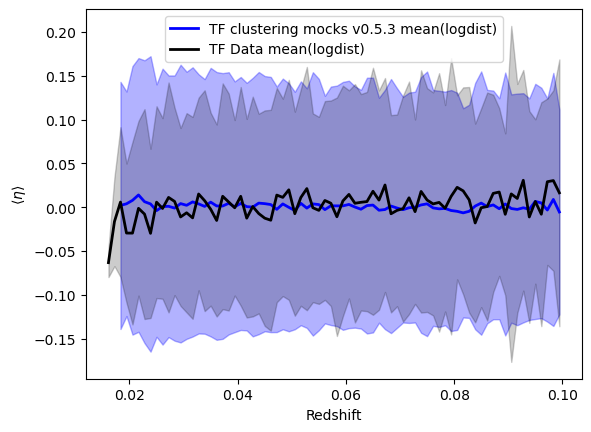

In [24]:
plt.plot(zcen, ld_stats['mean_of_mean'], 'b-', lw=2, label=f'TF clustering mocks {cfg.version_tf_clus} mean(logdist)')
plt.fill_between(zcen, 
                 ld_stats['mean_of_mean']-ld_stats['mean_of_std'],
                 ld_stats['mean_of_mean']+ld_stats['mean_of_std'], 
                 color='b', alpha=0.3)

plt.plot(zcen, d_ld_mean, 'k-', lw=2, label='TF Data mean(logdist)')
plt.fill_between(zcen, 
                 d_ld_mean-d_ld_std, 
                 d_ld_mean+d_ld_std, 
                 color='k', alpha=0.2)
plt.legend()
plt.xlabel('Redshift')
plt.ylabel(r'$\langle \eta \rangle$')

In [28]:
pvtrue_stats = get_stats(mocks, 'Z', 'PV_TRUE', zbins)
pvobs_stats = get_stats(mocks, 'Z', 'PV', zbins)

/tmp/ipykernel_65048/2000261273.py:5: RuntimeWarning: invalid value encountered in divide
  mean = mean/counts
/tmp/ipykernel_65048/2000261273.py:6: RuntimeWarning: invalid value encountered in divide
  var = var/counts - (mean)**2
/tmp/ipykernel_65048/2000261273.py:7: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(var)


Text(0.5, 0, 'Redshift')

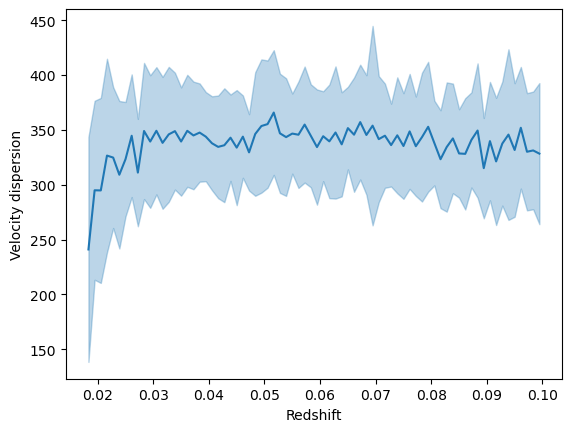

In [32]:
plt.plot(zcen, pvtrue_stats['mean_of_std'])
plt.fill_between(zcen, 
                 pvtrue_stats['mean_of_std']-pvtrue_stats['std_of_std'],
                 pvtrue_stats['mean_of_std']+pvtrue_stats['std_of_std'], color='C0', alpha=0.3)

#plt.plot(zcen, pvobs_stats['mean_of_std'])
#plt.fill_between(zcen, 
#                 pvobs_stats['mean_of_std']-pvobs_stats['std_of_std'],
#                 pvobs_stats['mean_of_std']+pvobs_stats['std_of_std'], color='C1', alpha=0.3)

plt.ylabel('Velocity dispersion')
plt.xlabel('Redshift')